In [1]:
import numpy as np
import pandas as pd
from polynomial_regression import PolynomialRegression




In [2]:
df=pd.read_csv('poly_train.csv')
X=df.drop('y',axis=1).values
y=df['y'].values.reshape(-1,1)

In [3]:
print("Before cleaning:")
print("X shape =", X.shape)
print("y shape =", y.shape)
print("Missing X =", np.isnan(X).sum())
print("Missing y =", np.isnan(y).sum())
df.isna().sum()


Before cleaning:
X shape = (1200, 7)
y shape = (1200, 1)
Missing X = 167
Missing y = 0


x0    21
x1    25
x2    30
x3    21
x4    12
x5    35
x6    23
y      0
dtype: int64

In [4]:
# ---- Step 1: remove rows where y is missing 
mask = ~np.isnan(y).flatten()
X = X[mask, :]
y = y[mask]


In [5]:
# ---- Step 2: fill missing values in X column-wise
for col in range(X.shape[1]):
    column = X[:, col]

    # find missing indices
    missing = np.isnan(column)

    if np.any(missing):
        # compute mean without nan
        mean_val = np.nanmean(column)

        # fill missing
        column[missing] = mean_val

    X[:, col] = column


In [6]:
print("After cleaning:")
print("X shape =", X.shape)
print("Missing X =", np.isnan(X).sum())

After cleaning:
X shape = (1200, 7)
Missing X = 0


In [7]:
np.random.seed(42)

n = X.shape[0]
indices = np.random.permutation(n)

split = int(0.8 * n)
train_idx = indices[:split]
cv_idx   = indices[split:]

X_train, X_cv = X[train_idx], X[cv_idx]
y_train, y_cv = y[train_idx], y[cv_idx]


In [8]:
mean=X_train.mean(axis=0)
std=X_train.std(axis=0)
X_train=(X_train-mean)/std
X_cv=(X_cv-mean)/std


In [9]:
def r2_score(y, y_pred):
    y = y.reshape(-1)
    y_pred = y_pred.reshape(-1)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res / ss_tot)


R2 score on CV set: 0.9309062754213107


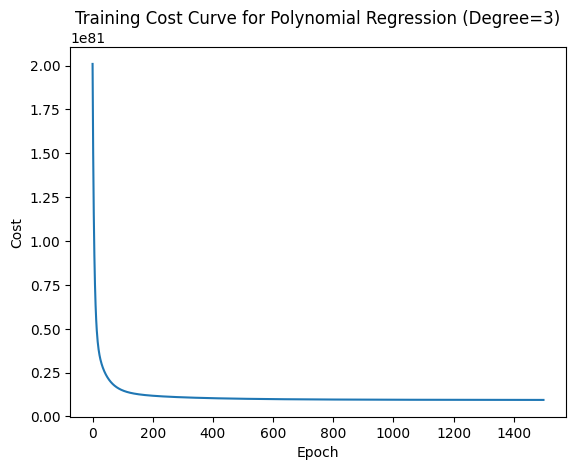

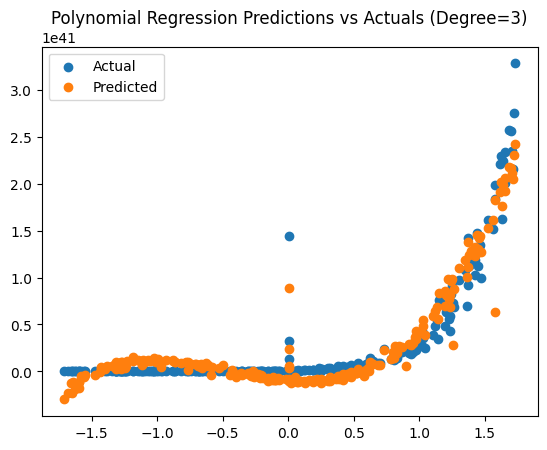

In [10]:

model=PolynomialRegression(degree=3, lr=0.01, epochs=1500, normalize=False) 
model.fit(X_train, y_train,verbose=False)
t_pred=model.predict(X_cv)
print("R2 score on CV set:", r2_score(y_cv,t_pred))
model.plot_cost_curve(Title='Training Cost Curve for Polynomial Regression (Degree=3)')
model.plot_data_points(X_cv[:,0], y_cv,y_pred=t_pred,Title='Polynomial Regression Predictions vs Actuals (Degree=3)')

In [11]:
df=pd.read_csv("poly_test.csv")
X_test=df
X_test=(X_test-mean)/std

In [12]:
test_preds=model.predict(X_test)

In [13]:
output_df = pd.DataFrame(test_preds, columns=['y'])
output_df.to_csv("test_predictions.csv", index=True)

print("Predictions saved to test_predictions.csv")


Predictions saved to test_predictions.csv
